# 15 — Vegas Odds vs Style Heatmap, Tabular Models, and Autoencoder+RF

**Goal:** On fights where we have **de-vigged closing-style odds** (notebook 14), compare **implied P(Vegas favorite wins)** to project signals evaluated on the **same test events** as notebook 13 (80% / 20% split by sorted `Event_Id_x`).

**Label:** Did the **Vegas favorite** (higher de-vigged implied prob) win? Name matching uses trimmed lower-case strings between odds names and `Fighter_A` / `Fighter_B`.

**Models scored:**
- **Vegas** — `max(p1, p2)` from notebook 14.
- **Heatmap** — style-pair win rate from notebook 11’s population matrix, with **favorite = Vegas side** (not Elo).
- **RF (Z-deltas)** — same as notebook 13.
- **HistGradientBoosting (Z-deltas)** — same hyperparameters as notebook 17.
- **Logistic regression L2 (Z-deltas)** — linear baseline on the same features.
- **XGBoost (Z-deltas)** — optional; requires `pip install xgboost`.
- **RF (AE embeddings)** — same autoencoder architecture as notebook 12; RF on train events only.

**Inputs:** `ufc_fight_stats_cleaned.csv`, `ufc_gmm_comparison.csv`, `ufc_modeling_data_final.csv`, `ufc_fight_odds_clean.csv`  
**Metrics (test, intersection where all predictions exist):** Brier, log loss, accuracy.

In [1]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 15_vegas_vs_predictions.ipynb | code cell index: 1
# Section (from markdown above): 15 — Vegas Odds vs Style Heatmap, Z-RF, and Autoencoder+RF
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# Joins tables on fighter, fight, or event keys.
# Fits or scores a supervised sklearn model.
# PyTorch: neural network definition and/or training loop.
# Standardizes features (mean 0, unit variance) where used.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Merges link fighters, fights, styles, or odds on shared keys.
#   • Pivot tables build matrices (e.g., style vs style win rates).
#   • RandomForest* fits on train rows; predict_proba yields calibrated-ish scores.
#   • Event-based holdout keeps entire cards in train or test (reduces leakage).
#   • PyTorch block: tensor shapes follow (batch, features); device may be CPU or CUDA.
#   • Scaler is fit on training-like data only when a split is explicit.
#   • Probabilities are clipped before log loss to avoid log(0).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss

# PyTorch is imported only in the autoencoder cell below. Importing torch before
# HistGradientBoosting (next cells) can segfault on macOS (OpenMP / native libs).

K_ELO = 32.0
ELO_INIT = 1500.0
ODDS_PATH = "../data/processed/ufc_fight_odds_clean.csv"

# --- Load cleaned fights + GMM style / Z-score table -------------------------
fights = pd.read_csv("../data/processed/ufc_fight_stats_cleaned.csv")
styles = pd.read_csv("../data/processed/ufc_gmm_comparison.csv")
cluster_col = "Cluster_k5"

style_map = styles[["Fighter", cluster_col]].set_index("Fighter")
z_cols = ["Sig_Str_PM_Z", "Takedown_Att_PM_Z", "Sub_Att_PM_Z", "Control_Ratio_Z"]
z_map = styles[["Fighter"] + z_cols].set_index("Fighter")

# --- Inner join: keep rows where BOTH fighters have cluster + Z features ----
df = fights.merge(style_map, left_on="Fighter", right_index=True, how="inner")
df = df.rename(columns={cluster_col: "Style_A"})
df = df.merge(style_map, left_on="Opponent", right_index=True, how="inner")
df = df.rename(columns={cluster_col: "Style_B"})
df["Win_A"] = df["Won"].astype(int)

# --- Empirical P(Fighter A wins | style A, style B) over all matchup rows ----
win_matrix = df.pivot_table(index="Style_A", columns="Style_B", values="Win_A", aggfunc="mean")


def expected_score(ra, rb):
    return 1.0 / (1.0 + 10.0 ** ((rb - ra) / 400.0))


# --- One row per fight (first fighter perspective = Fighter A) --------------
fight_1 = df.drop_duplicates(subset=["Fight_Id"], keep="first").copy()
fight_1 = fight_1.sort_values(["Event_Id_x", "Fight_Id"]).reset_index(drop=True)

elo = {}
rows = []
for _, r in fight_1.iterrows():
    a, b = r["Fighter"], r["Opponent"]
    ea = elo.get(a, ELO_INIT)
    eb = elo.get(b, ELO_INIT)
    exp_a = expected_score(ea, eb)
    score_a = 1.0 if r["Win_A"] == 1 else 0.0
    elo[a] = ea + K_ELO * (score_a - exp_a)
    elo[b] = eb + K_ELO * ((1.0 - score_a) - (1.0 - exp_a))
    rows.append(
        {
            "Fight_Id": r["Fight_Id"],
            "Event_Id_x": r["Event_Id_x"],
            "Fighter_A": a,
            "Fighter_B": b,
            "Win_A": r["Win_A"],
            "Style_A": int(r["Style_A"]),
            "Style_B": int(r["Style_B"]),
        }
    )

uf = pd.DataFrame(rows)


def add_z_diff(frame):
    out = frame.merge(z_map, left_on="Fighter_A", right_index=True, how="inner")
    out = out.merge(
        z_map, left_on="Fighter_B", right_index=True, how="inner", suffixes=("", "_B")
    )
    for c in z_cols:
        out[f"delta_{c}"] = out[c] - out[f"{c}_B"]
    return out


# --- Z-score *differences* A − B become RF features (notebook 13 alignment) -
ufz = add_z_diff(uf)
ufz["Fight_Id"] = ufz["Fight_Id"].astype(str)
feat_z = [f"delta_{c}" for c in z_cols]

# --- Time split: first 80% of distinct events train, last 20% test -----------
sorted_events = np.sort(ufz["Event_Id_x"].unique())
split_i = max(1, int(0.8 * len(sorted_events)))
train_ev = set(sorted_events[:split_i])
train_mask = ufz["Event_Id_x"].isin(train_ev)
test_mask = ~train_mask

print(f"Fights (styled, Z-complete): {len(ufz)}; test fights: {test_mask.sum()}")

Fights (styled, Z-complete): 5542; test fights: 1098


## Merge odds and define the Vegas-favorite label
Run notebook **14** first if `ufc_fight_odds_clean.csv` is missing.

In [2]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 15_vegas_vs_predictions.ipynb | code cell index: 3
# Section (from markdown above): Merge odds and define the Vegas-favorite label
# ------------------------------------------------------------------------
# Loads one or more CSV files (paths usually relative to notebooks/).
# Joins tables on fighter, fight, or event keys.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Merges link fighters, fights, styles, or odds on shared keys.

# --- Merge de-vigged odds from notebook 14 --------------------------------
odds = pd.read_csv(ODDS_PATH)
odds["Fight_Id"] = odds["Fight_Id"].astype(str)
ufz = ufz.merge(
    odds[
        [
            "Fight_Id",
            "fighter_1",
            "fighter_2",
            "p_fighter_1",
            "p_fighter_2",
        ]
    ],
    on="Fight_Id",
    how="left",
)

# --- Vegas favorite = side with larger de-vigged implied probability --------
m = ufz["p_fighter_1"].notna()
ufz["vegas_fav"] = pd.Series([pd.NA] * len(ufz), dtype="object", index=ufz.index)
ufz.loc[m, "vegas_fav"] = np.where(
    ufz.loc[m, "p_fighter_1"] >= ufz.loc[m, "p_fighter_2"],
    ufz.loc[m, "fighter_1"],
    ufz.loc[m, "fighter_2"],
)


def _norm(s):
    return str(s).strip().lower() if pd.notna(s) else np.nan


ufz["nA"] = ufz["Fighter_A"].map(_norm)
ufz["nB"] = ufz["Fighter_B"].map(_norm)
ufz["nv"] = ufz["vegas_fav"].map(_norm)
ufz["vegas_name_ok"] = m & ((ufz["nv"] == ufz["nA"]) | (ufz["nv"] == ufz["nB"]))

# --- Outcome label: did the Vegas favorite win? (name-normalized) -----------
ufz["winner_n"] = np.where(ufz["Win_A"] == 1, ufz["nA"], ufz["nB"])
ufz["y_vegas_fav_won"] = np.nan
ok = ufz["vegas_name_ok"]
ufz.loc[ok, "y_vegas_fav_won"] = (ufz.loc[ok, "nv"] == ufz.loc[ok, "winner_n"]).astype(float)

ufz["p_vegas_fav"] = np.nan
ufz.loc[m, "p_vegas_fav"] = np.maximum(
    ufz.loc[m, "p_fighter_1"], ufz.loc[m, "p_fighter_2"]
)

print(f"Rows with odds: {m.sum()}; name-aligned to card: {ufz['vegas_name_ok'].sum()}")

Rows with odds: 4248; name-aligned to card: 4242


In [3]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 15_vegas_vs_predictions.ipynb | code cell index: 4
# Section (from markdown above): Merge odds and define the Vegas-favorite label
# ------------------------------------------------------------------------
# Fits or scores a supervised sklearn model.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • RandomForest* fits on train rows; predict_proba yields calibrated-ish scores.

# --- Heatmap P(Vegas fav wins): cluster row = fav, col = dog -----------------
def heatmap_p_vegas_fav(row):
    if not row["vegas_name_ok"] or pd.isna(row["p_fighter_1"]):
        return np.nan
    nv, nA = row["nv"], row["nA"]
    ca, cb = int(row["Style_A"]), int(row["Style_B"])
    if nv == nA:
        cfav, cdog = ca, cb
    else:
        cfav, cdog = cb, ca
    return float(win_matrix.loc[cfav, cdog])


ufz["heatmap_p_vegas_fav"] = ufz.apply(heatmap_p_vegas_fav, axis=1)


def p_vegas_favorite_wins_from_p_a(row, p_a_wins):
    if not row["vegas_name_ok"] or pd.isna(p_a_wins):
        return np.nan
    if row["nv"] == row["nA"]:
        return float(p_a_wins)
    return float(1.0 - p_a_wins)


# --- Z-delta RF: same hyperparameters as notebook 13 ------------------------
clf_z = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
)
clf_z.fit(ufz.loc[train_mask, feat_z], ufz.loc[train_mask, "Win_A"])
p_a_z = clf_z.predict_proba(ufz[feat_z])[:, 1]
ufz["p_rf_z_vegas_fav"] = [
    p_vegas_favorite_wins_from_p_a(row, pa)
    for (_, row), pa in zip(ufz.iterrows(), p_a_z)
]

# --- Z-delta HistGradientBoosting + Logistic (notebook 17 alignment) -------
clf_hgb = HistGradientBoostingClassifier(
    max_iter=250, max_depth=8, learning_rate=0.06, random_state=42
)
clf_hgb.fit(ufz.loc[train_mask, feat_z], ufz.loc[train_mask, "Win_A"])
p_a_hgb = clf_hgb.predict_proba(ufz[feat_z])[:, 1]
ufz["p_hgb_z_vegas_fav"] = [
    p_vegas_favorite_wins_from_p_a(row, pa)
    for (_, row), pa in zip(ufz.iterrows(), p_a_hgb)
]

clf_lr = LogisticRegression(
    max_iter=1000, C=1.0, random_state=42, solver="lbfgs"
)
clf_lr.fit(ufz.loc[train_mask, feat_z], ufz.loc[train_mask, "Win_A"])
p_a_lr = clf_lr.predict_proba(ufz[feat_z])[:, 1]
ufz["p_lr_z_vegas_fav"] = [
    p_vegas_favorite_wins_from_p_a(row, pa)
    for (_, row), pa in zip(ufz.iterrows(), p_a_lr)
]

try:
    from xgboost import XGBClassifier

    clf_xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=1,
        eval_metric="logloss",
    )
    clf_xgb.fit(ufz.loc[train_mask, feat_z], ufz.loc[train_mask, "Win_A"])
    p_a_xgb = clf_xgb.predict_proba(ufz[feat_z])[:, 1]
    ufz["p_xgb_z_vegas_fav"] = [
        p_vegas_favorite_wins_from_p_a(row, pa)
        for (_, row), pa in zip(ufz.iterrows(), p_a_xgb)
    ]
except Exception as e:
    ufz["p_xgb_z_vegas_fav"] = np.nan
    print(
        "XGBoost skipped (install with pip install xgboost). Reason:", type(e).__name__, e
    )

## Autoencoder + RF (same event split as Z-RF)

This cell imports **PyTorch** (kept out of the first cell so **HistGradientBoosting** can run first—on some **macOS** setups, `import torch` before HGB can **segfault** the Jupyter kernel).

Trains the encoder on **all** fighters in `ufc_modeling_data_final.csv` (as in notebook 12), then fits a Random Forest on embedding features **only on train events** and scores test rows.

In [4]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 15_vegas_vs_predictions.ipynb | code cell index: 6
# Section (from markdown above): Autoencoder + RF (same event split as Z-RF)
# ------------------------------------------------------------------------
# Loads one or more CSV files (paths usually relative to notebooks/).
# Joins tables on fighter, fight, or event keys.
# Fits or scores a supervised sklearn model.
# PyTorch: neural network definition and/or training loop.
# Standardizes features (mean 0, unit variance) where used.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Merges link fighters, fights, styles, or odds on shared keys.
#   • RandomForest* fits on train rows; predict_proba yields calibrated-ish scores.
#   • PyTorch block: tensor shapes follow (batch, features); device may be CPU or CUDA.
#   • Scaler is fit on training-like data only when a split is explicit.

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

EPOCHS_AE = 80  # increase toward 200 to match notebook 12 more closely
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Fighter profiles for autoencoder (notebook 12 feature set) -------------
md = pd.read_csv("../data/processed/ufc_modeling_data_final.csv")
features = [
    "Sig_Str_PM_Z",
    "Takedown_Att_PM_Z",
    "Sub_Att_PM_Z",
    "Control_Ratio_Z",
    "Distance_Ratio",
    "Clinch_Ratio",
    "Ground_Ratio",
]
X_raw = md[features].dropna()
fighters_ae = md.loc[X_raw.index, "Fighter"].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)


# --- Encoder 7 → 16 → 3; decoder symmetric (MSE reconstruction) -------------
class StyleAutoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


ae = StyleAutoencoder(input_dim=X_tensor.shape[1], encoding_dim=3).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=0.01)
crit = nn.MSELoss()
for epoch in range(EPOCHS_AE):
    opt.zero_grad()
    enc, dec = ae(X_tensor)
    loss = crit(dec, X_tensor)
    loss.backward()
    opt.step()

with torch.no_grad():
    emb_np, _ = ae(X_tensor)
    emb_np = emb_np.cpu().numpy()

df_emb = pd.DataFrame(emb_np, columns=["Emb_1", "Emb_2", "Emb_3"])
df_emb["Fighter"] = fighters_ae

emb_a = df_emb.rename(
    columns={"Emb_1": "Emb_1_A", "Emb_2": "Emb_2_A", "Emb_3": "Emb_3_A"}
)
emb_b = df_emb.rename(
    columns={"Emb_1": "Emb_1_B", "Emb_2": "Emb_2_B", "Emb_3": "Emb_3_B"}
)

u = ufz.merge(emb_a, left_on="Fighter_A", right_on="Fighter", how="inner").drop(
    columns=["Fighter"]
)
u = u.merge(emb_b, left_on="Fighter_B", right_on="Fighter", how="inner").drop(
    columns=["Fighter"]
)

for j in range(1, 4):
    u[f"Diff_Emb{j}"] = u[f"Emb_{j}_A"] - u[f"Emb_{j}_B"]

feat_ae = [
    "Emb_1_A",
    "Emb_2_A",
    "Emb_3_A",
    "Emb_1_B",
    "Emb_2_B",
    "Emb_3_B",
    "Diff_Emb1",
    "Diff_Emb2",
    "Diff_Emb3",
]

# --- RF on embeddings: trained only on train *events* (fair vs Vegas) ------
clf_ae = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
)
tr = u["Event_Id_x"].isin(train_ev)
clf_ae.fit(u.loc[tr, feat_ae], u.loc[tr, "Win_A"])
p_a_ae = clf_ae.predict_proba(u[feat_ae])[:, 1]
u["p_rf_ae_vegas_fav"] = [
    p_vegas_favorite_wins_from_p_a(row, pa)
    for (_, row), pa in zip(u.iterrows(), p_a_ae)
]

ufz = ufz.drop(
    columns=["p_rf_ae_vegas_fav"], errors="ignore"
).merge(u[["Fight_Id", "p_rf_ae_vegas_fav"]], on="Fight_Id", how="left")

print(f"Rows with AE+RF Vegas-fav prob: {ufz['p_rf_ae_vegas_fav'].notna().sum()}")

Rows with AE+RF Vegas-fav prob: 4242


## Test metrics vs `y_vegas_fav_won`

Rows: **test events**, odds present, Vegas names align with the card, and **all listed model probabilities** non-missing (heatmap can still be NaN if matrix lookup fails; **XGBoost** is skipped if the column is all NaN).

              model   n  accuracy    brier  log_loss
              Vegas 776  0.622423 0.220969  0.631381
Heatmap (Vegas fav) 776  0.479381 0.250421  0.693967
        RF Z-deltas 776  0.612113 0.233780  0.659104
       HGB Z-deltas 776  0.559278 0.253033  0.704695
        LogReg L2 Z 776  0.621134 0.231783  0.655277
              RF AE 776  0.636598 0.220448  0.631531
       XGB Z-deltas 776  0.579897 0.242661  0.678942


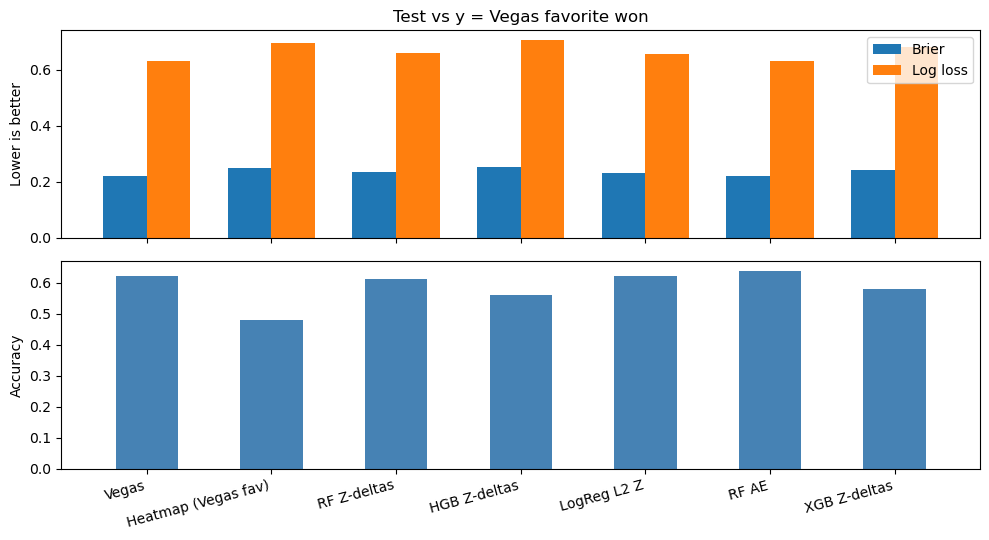

In [5]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 15_vegas_vs_predictions.ipynb | code cell index: 8
# Section (from markdown above): Test metrics vs `y_vegas_fav_won`
# ------------------------------------------------------------------------
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Probabilities are clipped before log loss to avoid log(0).

# --- Compare all models on the same test rows (complete cases only) ---------
cols = {
    "Vegas": "p_vegas_fav",
    "Heatmap (Vegas fav)": "heatmap_p_vegas_fav",
    "RF Z-deltas": "p_rf_z_vegas_fav",
    "HGB Z-deltas": "p_hgb_z_vegas_fav",
    "LogReg L2 Z": "p_lr_z_vegas_fav",
    "RF AE": "p_rf_ae_vegas_fav",
}
if (
    "p_xgb_z_vegas_fav" in ufz.columns
    and ufz["p_xgb_z_vegas_fav"].notna().any()
):
    cols["XGB Z-deltas"] = "p_xgb_z_vegas_fav"

sub = ufz.loc[test_mask].copy()
sub = sub.dropna(subset=["y_vegas_fav_won"] + list(cols.values()))
y = sub["y_vegas_fav_won"].astype(int)

# --- Clip probabilities for numerical stability in log loss -----------------
EPS = 1e-6


def metrics_block(name, p):
    p = np.asarray(p, dtype=float)
    p_clip = np.clip(p, EPS, 1.0 - EPS)
    return {
        "model": name,
        "n": len(p),
        "accuracy": accuracy_score(y, (p >= 0.5).astype(int)),
        "brier": brier_score_loss(y, p),
        "log_loss": log_loss(y, p_clip),
    }


rows_m = [metrics_block(nm, sub[c]) for nm, c in cols.items()]
met = pd.DataFrame(rows_m)
print(met.to_string(index=False))

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
x = np.arange(len(met))
w = 0.35
ax0.bar(x - w / 2, met["brier"], width=w, label="Brier")
ax0.bar(x + w / 2, met["log_loss"], width=w, label="Log loss")
ax0.set_ylabel("Lower is better")
ax0.legend(loc="upper right")
ax0.set_title("Test vs y = Vegas favorite won")
ax1.bar(x, met["accuracy"], width=0.5, color="steelblue")
ax1.set_ylabel("Accuracy")
ax1.set_xticks(x)
ax1.set_xticklabels(met["model"], rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Takeaway for write-ups

- **Vegas** is the natural **baseline** for probability quality on `P(favorite wins)` when the favorite is defined by the market.
- **HGB / LogReg / XGB** use the same Z-deltas as RF; notebook **17** compares them on `Win_A` only—here they are scored on **did the Vegas favorite win**, alongside Vegas itself.
- Project models use **static career summaries** (and AE on the same), so they are not a fair **causal** pre-fight snapshot; treat gains/losses vs Vegas as **descriptive** on this split.
- If **name match rate** is low, tighten string normalization (accents, nicknames) or match on `fighter_*_url` slugs in a future revision.